# IMPORTS

In [155]:
import glob
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
from sklearn import tree
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn.model_selection import train_test_split

# FILTERS

In [156]:
def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def butter_highpass_filter(data, cutoff, fs, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='highpass', analog=False)
    y = filtfilt(b, a, data)
    return y

def bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

# Feature Extraction

In [157]:
def feature_extraction(data, state):
    df = data['filtered_EA'].dropna().values
    
    # center signal to improve ZCR accuracy
    centered = df - np.mean(df)
    
    return {
        'mean': [np.mean(df)],
        'std': [np.std(df)],
        'max': [np.max(df)],
        'min': [np.min(df)],
        'range': [np.max(df) - np.min(df)],
        'zcr': [(np.diff(np.sign(centered)) != 0).sum() / len(centered)],
        'diff_mean': [np.mean(np.abs(np.diff(df)))],
        'label': state
    }

# EA Detection

In [158]:
def ea_detection(csv_file_path):
    # Load data
    df = pd.read_csv(csv_file_path)
    df['time[s]'] = (df['LocalTimestamp'] - df['LocalTimestamp'].iloc[0])

    df = df.loc[(df['time[s]'] > 120) & (df['time[s]']  < (df['time[s]'].iloc[-1])-120)]
    
    ea_raw = df['EA'].astype(float)
    time = df['time[s]']
    sampling_rate = 15          
    
    ea_filtered = butter_lowpass_filter(ea_raw, 0.5, sampling_rate)
    smoothed = gaussian_filter1d(ea_filtered, sigma=5) 

    df['filtered_EA'] = smoothed

    #gaussian not necessary for ea
    # first cut first and last set of seconds
    #emotibit, collecting data on forehead

    plt.figure(figsize=(14, 5))
    plt.plot(time, ea_raw, color = 'red')
    plt.title("Raw EA")
    plt.xlabel("Time (s)")
    plt.ylabel("EA")
    #plt.xlim(120, (df['time[s]'].iloc[-1])-120)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(time, smoothed, color = 'red')
    plt.title("Filtered EA")
    plt.xlabel("Time (s)")
    plt.ylabel("EA")
    #plt.xlim(120, (df['time[s]'].iloc[-1])-120)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df


# ML Model

In [159]:
def decision_tree(frames):
    X = frames.drop('label', axis=1) #drops 'label' column
    y = frames['label']

    #splits into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=3)

    #trains model?
    dt_model.fit(X_train, y_train)

    #predicts 'y' values with test 'x' values
    y_pred = dt_model.predict(X_test)

    #checks accuracy of predicted 'y' against true 'y'
    acc = accuracy_score(y_test, y_pred)

    # confusion matrix
    dt_cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

    # precision, recall, f1 score
    print(classification_report(y_test, y_pred))

    print("Accuracy on set:", acc)

C:\Users\omshr\AppData\Local\Temp\ipykernel_24856\1091178029.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


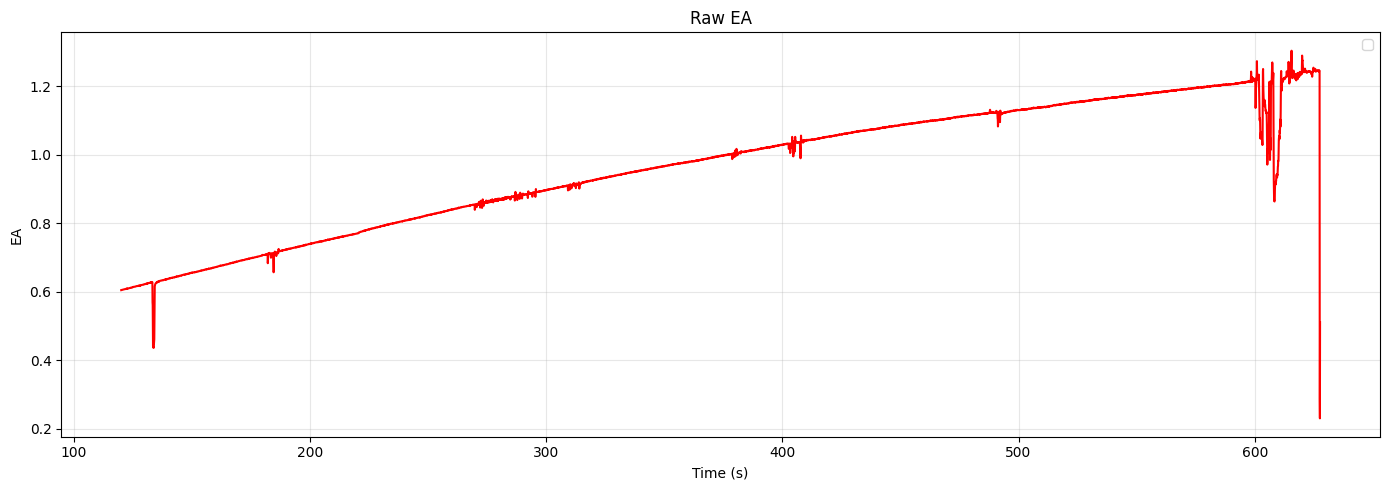

C:\Users\omshr\AppData\Local\Temp\ipykernel_24856\1091178029.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


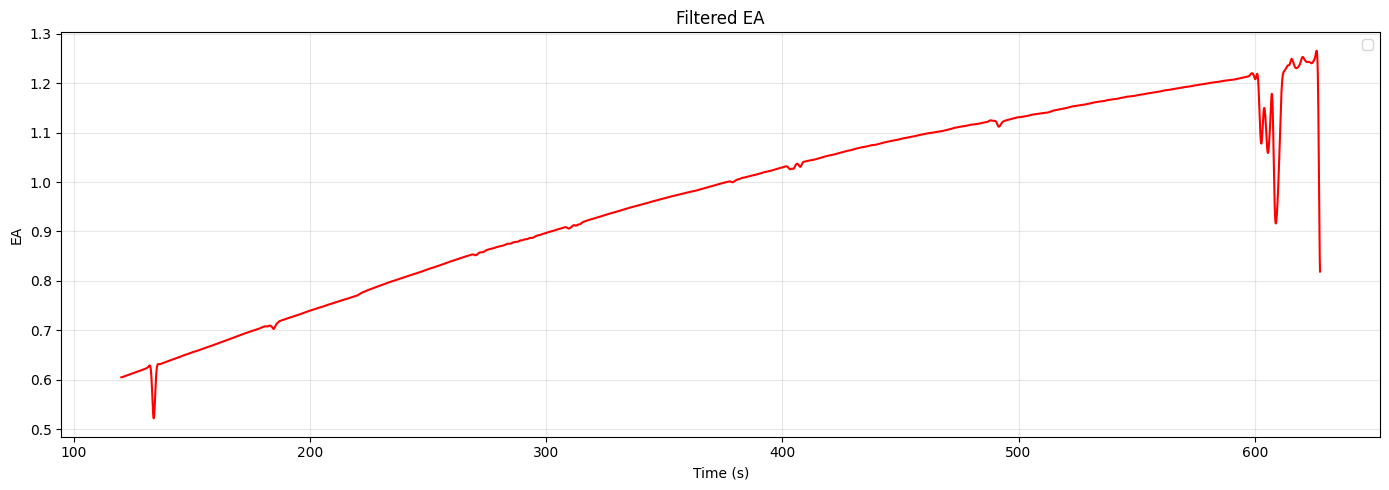

C:\Users\omshr\AppData\Local\Temp\ipykernel_24856\1091178029.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


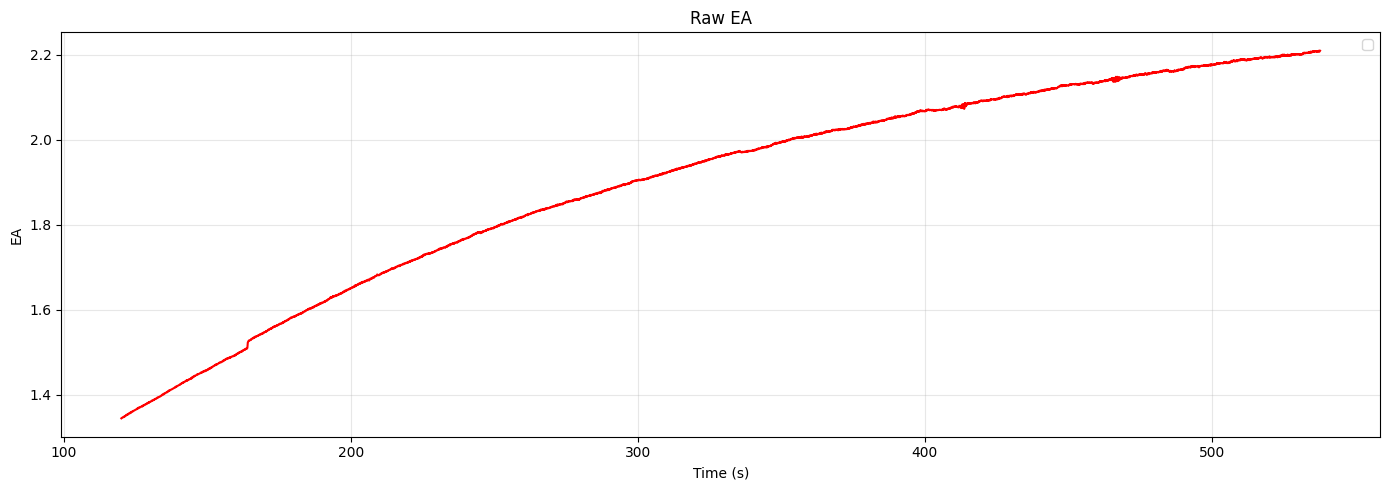

C:\Users\omshr\AppData\Local\Temp\ipykernel_24856\1091178029.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


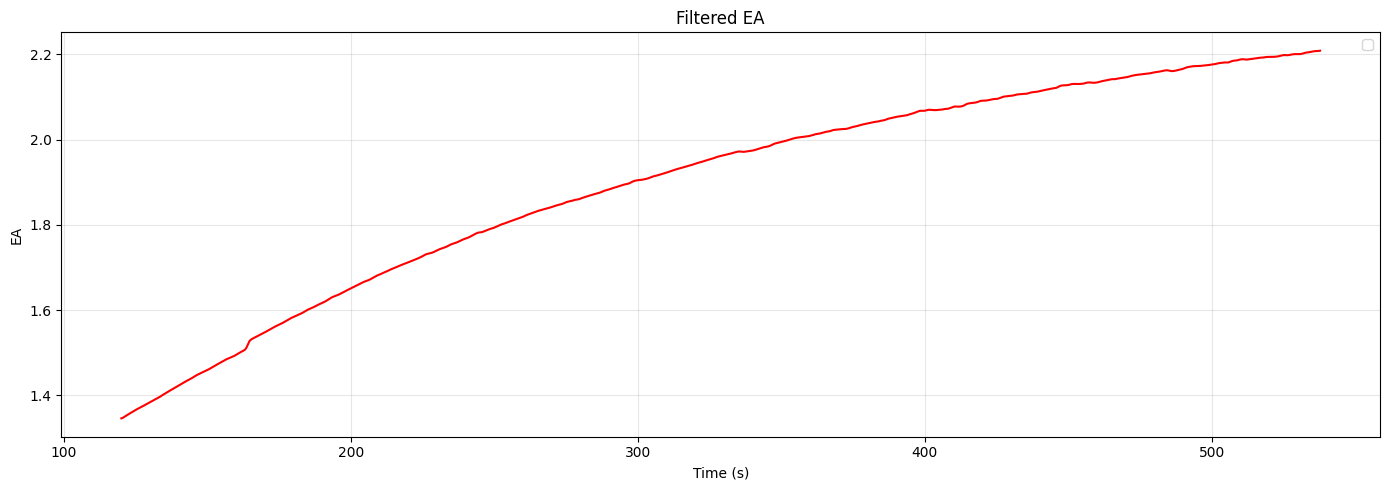

C:\Users\omshr\AppData\Local\Temp\ipykernel_24856\1091178029.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


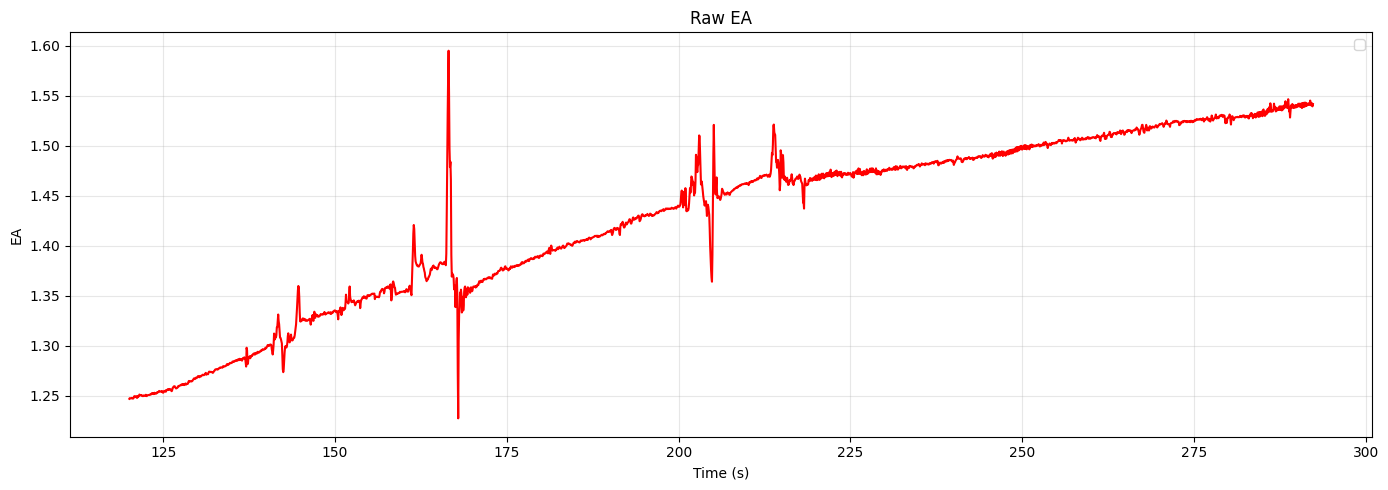

C:\Users\omshr\AppData\Local\Temp\ipykernel_24856\1091178029.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


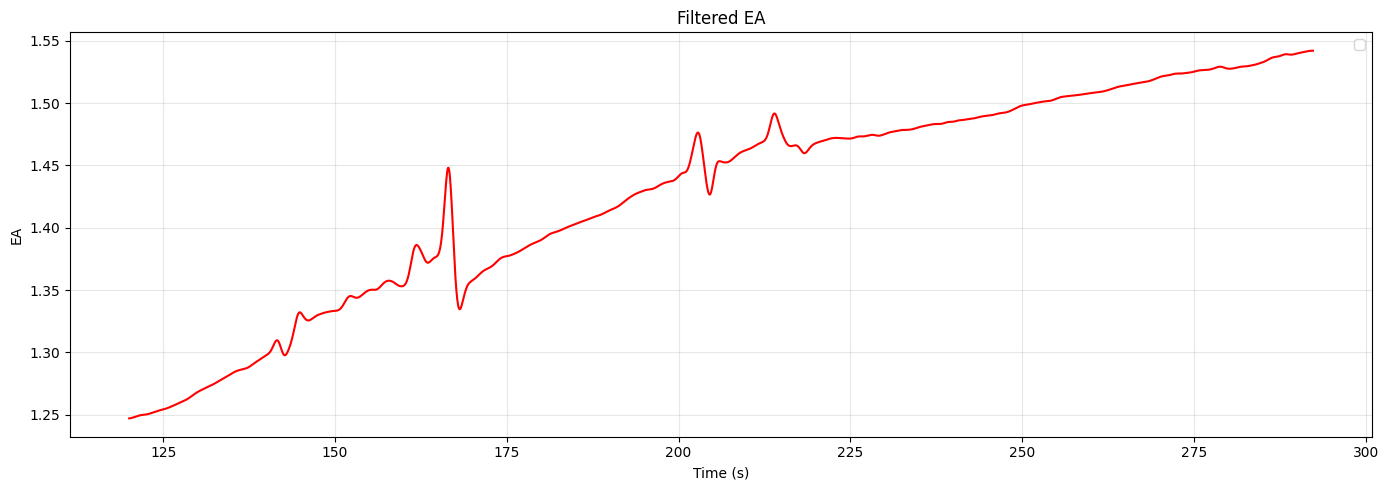

       mean       std       max       min     range       zcr  diff_mean  \
0  0.966411  0.182624  1.265632  0.521901  0.743730  0.000525   0.000326   
1  1.898815  0.242433  2.208655  1.345909  0.862746  0.000160   0.000140   
2  1.426944  0.084882  1.541986  1.247155  0.294831  0.001934   0.000299   

     label  
0  relaxed  
1  relaxed  
2  engaged  
              precision    recall  f1-score   support

     relaxed       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1

Accuracy on set: 1.0


In [160]:
# Run detection

file1 = '2025-07-10_EA_relaxed.csv'
file2 = '2025-07-15_EA_relaxed.csv'
file3 = '2025-07-08_EA_engaged.csv'

df1 = ea_detection(file1)
df2 = ea_detection(file2)
df3 = ea_detection(file3)

fd1 = feature_extraction(df1, 'relaxed')
fd2 = feature_extraction(df2, 'relaxed')
fd3 = feature_extraction(df3, 'engaged')

data = pd.DataFrame(fd1)
data = pd.concat([data, pd.DataFrame(fd2)], ignore_index = True)
data = pd.concat([data, pd.DataFrame(fd3)], ignore_index = True)

print(data)

decision_tree(data)

